# Lab: Classification: Predicting Left-Handedness from Psychological Factors

---

One way to define the data science process is as follows:

1. Obtain the data.
2. Explore the data.
3. Model the data.
4. Evaluate the model.
5. Explain.

We'll walk through a full data science problem in this lab. 

---

You're currently a data scientist working at a university. A professor of psychology is attempting to study the relationship between personalities and left-handedness. They have tasked you with gathering evidence so that they may publish.

> You might find it helpful to check out the codebook in the repo for some inspiration.

---
## Importing Libraries

In [5]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and Pipeline creation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from myutil import evaluate_skewness

## Obtain the data.

### Read in the file titled "data.csv":
> Hint: Despite being saved as a .csv file, you won't be able to simply `pd.read_csv()` this data!

In [6]:
# Load and view a smaple of the data
survey = pd.read_csv('data.csv')
survey.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,testelapse,country,fromgoogle,engnat,age,education,gender,race,religion,hand
0,4,1,5,1,5,1,5,1,4,1,...,232,US,2,1,22,3,1,3,2,3
1,1,5,1,4,2,5,5,4,1,5,...,247,CA,2,1,14,1,2,6,1,1
2,1,2,1,1,5,4,3,2,1,4,...,6774,NL,2,2,30,4,1,1,1,2
3,1,4,1,5,1,4,5,4,3,5,...,1072,US,2,1,18,2,2,3,2,2
4,5,1,5,1,5,1,5,1,3,1,...,226,US,2,1,22,3,1,3,2,3


---

## Explore the data.

### Conduct background research:

Domain knowledge is irreplaceable. Figuring out what information is relevant to a problem, or what data would be useful to gather, is a major part of any end-to-end data science project! For this lab, you'll be using a dataset that someone else has put together, rather than collecting the data yourself.

Do some background research about personality and handedness. What features, if any, are likely to help you make good predictions? How well do you think you'll be able to model this? Write a few bullet points summarizing what you believe, and remember to cite external sources.

You don't have to be exhaustive here. Do enough research to form an opinion, and then move on.

> You'll be using the answers to Q1-Q44 for modeling; you can disregard other features, e.g. country, age, internet browser.

In [7]:
survey.columns

Index(['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11',
       'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21',
       'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31',
       'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'Q39', 'Q40', 'Q41',
       'Q42', 'Q43', 'Q44', 'introelapse', 'testelapse', 'country',
       'fromgoogle', 'engnat', 'age', 'education', 'gender', 'race',
       'religion', 'hand'],
      dtype='str')

In [8]:
# Filter your data to include Q1 to Q44 and hand
survey = survey[['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11',
       'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21',
       'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31',
       'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'Q39', 'Q40', 'Q41',
       'Q42', 'Q43', 'Q44','hand']]

### Conduct exploratory data analysis on this dataset:

If you haven't already, be sure to check out the codebook in the repo, as that will help in your EDA process.

You might use this section to perform data cleaning if you find it to be necessary.

In [9]:
# Check Data Information
survey.info()

<class 'pandas.DataFrame'>
RangeIndex: 4184 entries, 0 to 4183
Data columns (total 45 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Q1      4184 non-null   int64
 1   Q2      4184 non-null   int64
 2   Q3      4184 non-null   int64
 3   Q4      4184 non-null   int64
 4   Q5      4184 non-null   int64
 5   Q6      4184 non-null   int64
 6   Q7      4184 non-null   int64
 7   Q8      4184 non-null   int64
 8   Q9      4184 non-null   int64
 9   Q10     4184 non-null   int64
 10  Q11     4184 non-null   int64
 11  Q12     4184 non-null   int64
 12  Q13     4184 non-null   int64
 13  Q14     4184 non-null   int64
 14  Q15     4184 non-null   int64
 15  Q16     4184 non-null   int64
 16  Q17     4184 non-null   int64
 17  Q18     4184 non-null   int64
 18  Q19     4184 non-null   int64
 19  Q20     4184 non-null   int64
 20  Q21     4184 non-null   int64
 21  Q22     4184 non-null   int64
 22  Q23     4184 non-null   int64
 23  Q24     4184 non-null   

In [10]:
# Summary Stat.
survey.describe()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,hand
count,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,...,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000
mean,1.962715,3.829589,2.846558,3.186902,2.865440,3.672084,3.216539,3.184512,2.761233,3.522945,...,2.610660,3.465344,2.798757,2.569312,2.984226,3.385277,2.704828,2.676386,2.736616,1.190966
std,1.360291,1.551683,1.664804,1.476879,1.545798,1.342238,1.490733,1.387382,1.511805,1.242890,...,1.409707,1.521460,1.413584,1.621772,1.483752,1.423055,1.544345,1.523097,1.471845,0.495357
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,1.000000,2.000000,1.000000,3.000000,2.000000,2.000000,1.000000,3.000000,...,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,5.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,4.000000,...,2.000000,4.000000,3.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000,1.000000
75%,3.000000,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,4.000000,5.000000,...,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,1.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000


In [11]:
# Check for nulls
survey.isnull().sum()

Q1      0
Q2      0
Q3      0
Q4      0
Q5      0
Q6      0
Q7      0
Q8      0
Q9      0
Q10     0
Q11     0
Q12     0
Q13     0
Q14     0
Q15     0
Q16     0
Q17     0
Q18     0
Q19     0
Q20     0
Q21     0
Q22     0
Q23     0
Q24     0
Q25     0
Q26     0
Q27     0
Q28     0
Q29     0
Q30     0
Q31     0
Q32     0
Q33     0
Q34     0
Q35     0
Q36     0
Q37     0
Q38     0
Q39     0
Q40     0
Q41     0
Q42     0
Q43     0
Q44     0
hand    0
dtype: int64

__Quick Question: What type of values do features Q1 to Q44 contain? (NOT datatype)__

> ordinal


__[Use Spearman Correlation](https://www.geeksforgeeks.org/data-science/spearmans-rank-correlation/)__

Spearman correlation refers to a nonparametric statistical technique used to assess the strength and direction of the relationship between the ranks of two ordinal variables, which can be either quantitative or qualitative. It ranges from −1 to +1, with values indicating perfect negative or positive relationships, respectively, and a value of 0 signifying no relationship, while being less affected by outliers. _**- ScienceDirect**_

In [12]:
# Check correlation using 'spearman'
survey.corr(method='spearman')

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,hand
Q1,1.000000,-0.118039,0.281336,-0.051184,0.209358,-0.067870,0.177012,-0.130499,0.241865,-0.052877,...,-0.068738,0.173360,-0.051918,0.296961,-0.073650,0.161472,-0.050000,0.210551,-0.078729,0.038819
Q2,-0.118039,1.000000,-0.007345,0.267212,-0.049983,0.144341,-0.096585,0.132858,-0.086902,0.140719,...,0.211084,-0.080983,0.233455,-0.035505,0.246509,-0.121881,0.226816,-0.017865,0.290222,-0.019378
Q3,0.281336,-0.007345,1.000000,0.071939,0.278312,-0.014694,0.223326,-0.115027,0.428076,-0.029851,...,-0.007055,0.241841,-0.031986,0.496725,-0.042545,0.218153,0.001283,0.275394,-0.003149,0.040980
Q4,-0.051184,0.267212,0.071939,1.000000,0.060906,0.074410,-0.042319,0.143752,-0.066036,0.051144,...,0.240342,-0.074810,0.376024,0.028491,0.223322,-0.026561,0.329851,0.014976,0.339992,0.011445
Q5,0.209358,-0.049983,0.278312,0.060906,1.000000,0.080643,0.252083,-0.045991,0.232806,0.008229,...,-0.018837,0.173966,0.031545,0.250027,-0.010353,0.205186,0.018918,0.263878,0.012083,0.034693
Q6,-0.067870,0.144341,-0.014694,0.074410,0.080643,1.000000,0.023930,0.088452,-0.029934,0.195167,...,0.008849,0.087662,0.041473,-0.010416,-0.015350,0.031272,0.115456,0.032794,0.109505,-0.014195
Q7,0.177012,-0.096585,0.223326,-0.042319,0.252083,0.023930,1.000000,-0.067351,0.255081,-0.022741,...,-0.085344,0.174003,-0.068336,0.206541,-0.085669,0.169673,-0.053980,0.188347,-0.065370,0.030956
Q8,-0.130499,0.132858,-0.115027,0.143752,-0.045991,0.088452,-0.067351,1.000000,-0.087505,0.033157,...,0.201087,-0.109051,0.236575,-0.144709,0.179640,-0.102912,0.156070,-0.125147,0.163933,-0.030309
Q9,0.241865,-0.086902,0.428076,-0.066036,0.232806,-0.029934,0.255081,-0.087505,1.000000,0.003859,...,-0.059759,0.266650,-0.122573,0.357504,-0.107155,0.187735,-0.072271,0.257732,-0.082525,0.011307
Q10,-0.052877,0.140719,-0.029851,0.051144,0.008229,0.195167,-0.022741,0.033157,0.003859,1.000000,...,0.033136,0.080323,0.046296,-0.022915,0.043763,-0.035516,0.126273,0.024406,0.091335,-0.018156


__Inspect the Target__

**Quick Question:** What does each number in the target column represent?
> it refers to what hand that used
> - 1 = Right hand
> - 2 = Left hand
> - 3 = Both hands
> - 0 may reffer that the value is missing

In [13]:
# Target Distribution, What do the numbers represents? hmmm...something is off. What do you notice?


In [14]:
# What needs to be removed from the Target?
survey.drop(index= survey[survey['hand'] == 0].index, inplace=True)
survey.value_counts('hand')

hand
1    3542
2     452
3     179
Name: count, dtype: int64

In [15]:
# We can tackle the following either by:
# 1. Strictly focusing on Left handed only
# 2. We can consider both handed as left handed since they use their left hand
# What will you choose?

survey[survey['hand'] == 3] = 2
survey.value_counts('hand')

hand
1    3542
2     631
Name: count, dtype: int64

In [16]:
survey['hand'] = survey['hand'].map({1:0,2:1})
survey.value_counts('hand')

hand
0    3542
1     631
Name: count, dtype: int64

## Let's see which performs the best: SVM vs. Random Forest vs. XGBoost
1. Tryout building a base model for each.
2. Improve each model using Grid Search and Pipelines.

### Data Splitting

In [17]:
# Identify your X and y
X = survey.drop(columns=['hand'])
y = survey['hand']

In [18]:
# Split the data to train and test for each X and y
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state=42, shuffle=True, stratify=y)

In [19]:
ss = StandardScaler()
# since we are both regularizing and using distance
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

### Building the Base Model
__Note:__ Using Pipeline ensures that the StandardScaler is applied properly—fitting only on the training data to prevent data leakage, and then transforming both the training and testing data.

In [20]:
# SVM Base Model
from sklearn.svm import LinearSVC, SVC
svm_base = LinearSVC()
svm_base.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [21]:
# Random Forest Base Model
rf_base = RandomForestClassifier()
rf_base.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
# XGBoost Base Model
from xgboost import XGBClassifier
xgboost_base = XGBClassifier()
xgboost_base.fit(X_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


__Checking the Base Models performance__

In [23]:
# SVM Base Model Result
print('SVM train score:', svm_base.score(X_train,y_train))
print('SVM test score:', svm_base.score(X_test,y_test))

SVM train score: 0.8493109646494907
SVM test score: 0.8491017964071856


In [24]:
# Random Forest Base Model Result
# SVM Base Model Result
print('random forest train score:', rf_base.score(X_train,y_train))
print('random forest test score:', rf_base.score(X_test,y_test))

random forest train score: 1.0
random forest test score: 0.895808383233533


In [25]:
# XGBoost Model Result
print('sgboost train score:', xgboost_base.score(X_train,y_train))
print('sgboost test score:', xgboost_base.score(X_test,y_test))

sgboost train score: 1.0
sgboost test score: 0.8922155688622755


__Comparing the base model performance__

In [26]:
# This is one good function to add to you collection
def evaluate_model_performance(model, X_test, y_test, target_names):
    """
    Generates predictions, displays the classification report and confusion matrix.
    """
    
    # Generate predictions
    y_pred = model.predict(X_test)
    
    # Display the Classification Report
    print("======================================================")
    print("                CLASSIFICATION REPORT                 ")
    print("======================================================")
    print(classification_report(y_test, y_pred, target_names=target_names,zero_division=0.0))
    
    # Display Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_names, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

__1. SVM Base Model Performance__

                CLASSIFICATION REPORT                 
                precision    recall  f1-score   support

Right-hand (0)       0.85      1.00      0.92       709
 Left/both (1)       0.00      0.00      0.00       126

      accuracy                           0.85       835
     macro avg       0.42      0.50      0.46       835
  weighted avg       0.72      0.85      0.78       835



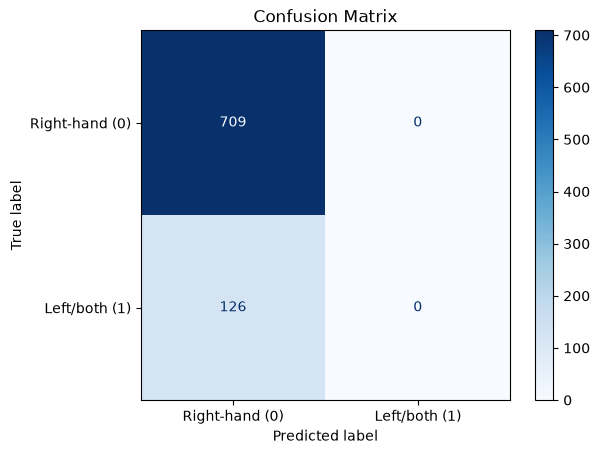

In [27]:
# SVM Base Model Performance
target_classes = ['Right-hand (0)', 'Left/both (1)']
evaluate_model_performance(svm_base,X_test, y_test, target_classes)

__2. Random Forest Base Model Performance__

                CLASSIFICATION REPORT                 
                precision    recall  f1-score   support

Right-hand (0)       0.89      1.00      0.94       709
 Left/both (1)       1.00      0.31      0.47       126

      accuracy                           0.90       835
     macro avg       0.95      0.65      0.71       835
  weighted avg       0.91      0.90      0.87       835



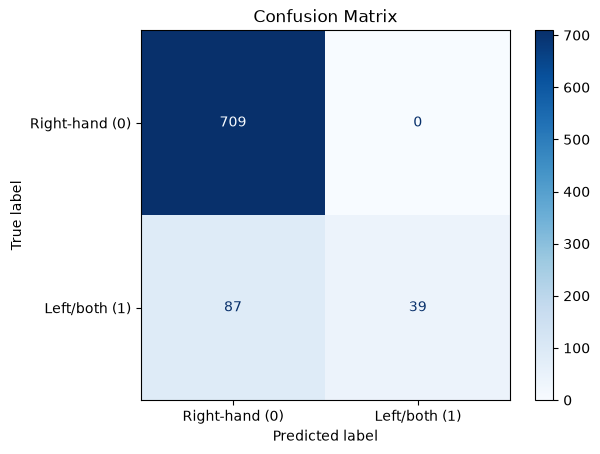

In [28]:
# Random Forest Base Model Performance
evaluate_model_performance(rf_base,X_test, y_test, target_classes)

__3. XGBoost Base Model Performance__

                CLASSIFICATION REPORT                 
                precision    recall  f1-score   support

Right-hand (0)       0.89      0.99      0.94       709
 Left/both (1)       0.86      0.34      0.49       126

      accuracy                           0.89       835
     macro avg       0.88      0.67      0.71       835
  weighted avg       0.89      0.89      0.87       835



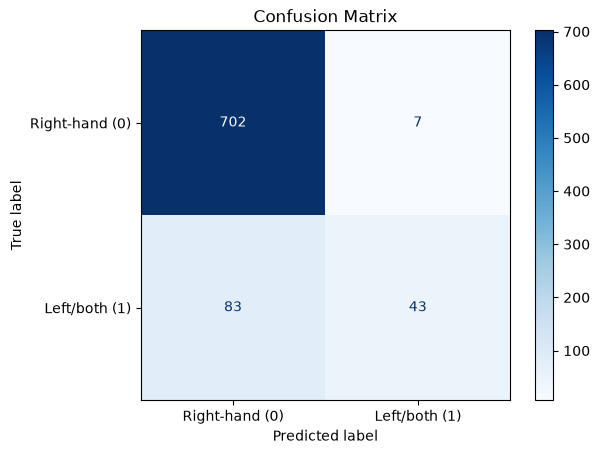

In [29]:
# XGBoost Base Model Performance
evaluate_model_performance(xgboost_base,X_test, y_test, target_classes)

## Grid Search
Now that we've set up the base models and established why default accuracy can be misleading, let's move on to hyperparameter tuning with GridSearchCV.

__Key Concept:__ Parameter Naming in Pipelines

When tuning a model inside a Pipeline, GridSearchCV requires a specific syntax to know which step the hyperparameter belongs to:

>`step_name__parameter_name`

__*Note:*__ Always use a double underscore (__) between the pipeline step name (e.g., 'logreg') and the parameter name (e.g., 'C'). Writing logreg_C instead of logreg__C is one of the most common errors when tuning pipelines!

In [30]:
# SVM Grid Search Parameters
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge'],
    'max_iter': [1000, 2000, 5000, 10000]
}

In [31]:
# Random Forest Grid Search Parameters
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30]
}

In [32]:
# XXGBoost Grid Search Parameters
xgboost_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 6]
}

__Setting up and fitting GridSearch__

/Users/zainababdulwahab/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/zainababdulwahab/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/zainababdulwahab/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/zainababdulwahab/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/zainababdulwahab/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best Parameters: {'C': 100, 'loss': 'hinge', 'max_iter': 1000}
Best CV F1-Score: 0.2991932100193744
                CLASSIFICATION REPORT                 
                precision    recall  f1-score   support

Right-hand (0)       0.89      0.74      0.81       709
 Left/both (1)       0.25      0.48      0.33       126

      accuracy                           0.70       835
     macro avg       0.57      0.61      0.57       835
  weighted avg       0.79      0.70      0.74       835



/Users/zainababdulwahab/GA_DSB/ga_dsb_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


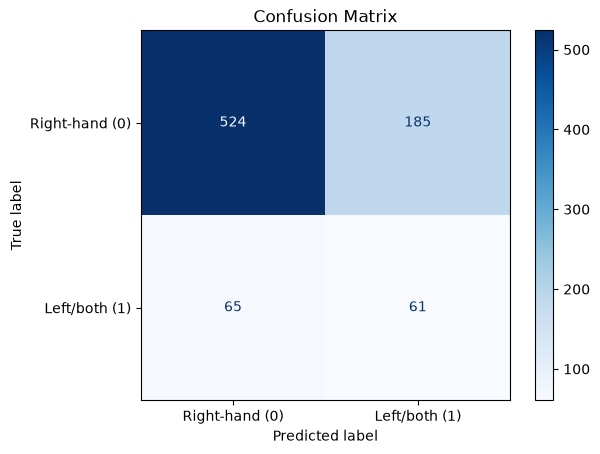

CPU times: user 401 ms, sys: 88.4 ms, total: 489 ms
Wall time: 4.39 s


In [34]:
%%time
# Setting up and fitting GridSearch for SVM
grid_svm = GridSearchCV(
    estimator= LinearSVC(),
    param_grid= svm_param_grid,
    cv= 5,
    scoring= "f1",
    n_jobs= -1
)

# Fit on training data
grid_svm.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_svm.best_params_)
print("Best CV F1-Score:", grid_svm.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(grid_svm.best_estimator_, X_test, y_test, target_classes)

Best Parameters: {'max_depth': None, 'n_estimators': 300}
Best CV F1-Score: 0.43635266087074875
                CLASSIFICATION REPORT                 
                precision    recall  f1-score   support

Right-hand (0)       0.89      1.00      0.94       709
 Left/both (1)       1.00      0.31      0.47       126

      accuracy                           0.90       835
     macro avg       0.95      0.65      0.71       835
  weighted avg       0.91      0.90      0.87       835



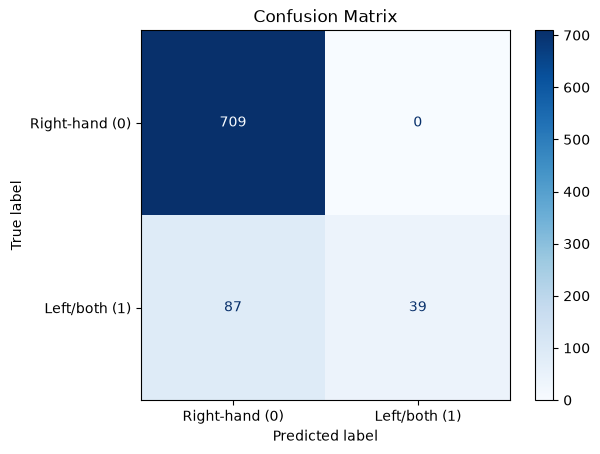

In [35]:
# Setting up and fitting GridSearch for Random Forest
grid_rf = GridSearchCV(
    estimator= RandomForestClassifier(), 
    param_grid= rf_param_grid, 
    cv = 5, 
    scoring = "f1", 
    n_jobs = -1
)
    

# Fit on training data
grid_rf.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_rf.best_params_)
print("Best CV F1-Score:", grid_rf.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(grid_rf.best_estimator_, X_test, y_test, target_classes)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV F1-Score: 0.4371537070990804
                CLASSIFICATION REPORT                 
                precision    recall  f1-score   support

Right-hand (0)       0.89      1.00      0.94       709
 Left/both (1)       1.00      0.31      0.47       126

      accuracy                           0.90       835
     macro avg       0.95      0.65      0.71       835
  weighted avg       0.91      0.90      0.87       835



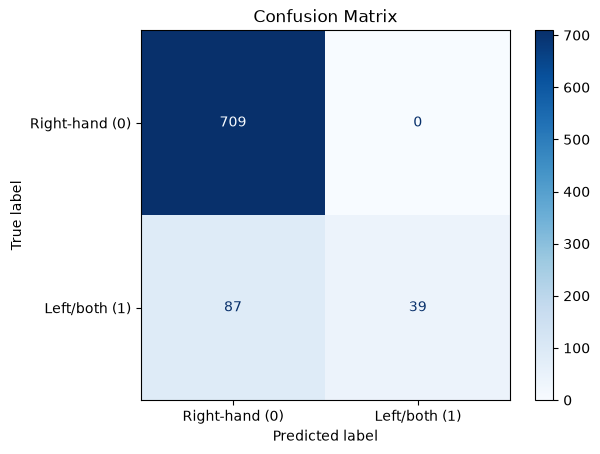

CPU times: user 134 ms, sys: 107 ms, total: 241 ms
Wall time: 837 ms


In [36]:
%%time
# Setting up and fitting GridSearch for XGBoost
grid_xgb = GridSearchCV(
    estimator= XGBClassifier(), 
    param_grid= xgboost_param_grid, 
    cv = 5,
    scoring = "f1",
    n_jobs= -1
)

# Fit on training data
grid_xgb.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_xgb.best_params_)
print("Best CV F1-Score:", grid_xgb.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(grid_xgb.best_estimator_, X_test, y_test, target_classes)

## Final Model Selection and Justification
Now that you have built, tuned, and evaluated all three models (SVM, Random Forest, and XGBoost), you must choose one model as your final production model.

Write a short justification to your selection. Your response must clearly address the following four points:

- __The Winning Model:__ Explicitly state which tuned model you are selecting.
- __Metric-Driven Justification:__ Defend your choice using the correct evaluation metrics. Explain why you relied on metrics like F1-Score or Recall for the minority class (Left-Handed) rather than overall Accuracy.
- __Model Comparison:__ Briefly explain why you rejected the other two models. (e.g., Did they struggle with recall? Were they computationally too expensive? Were they uninterpretable "black boxes"?)
- __Real-World Application:__ Explain how your chosen model serves the actual goal of this behavioral study. For example, if your model allows for feature extraction, how could psychologists use that information?

### Example Response Structure (Do not copy verbatim):
> __Final Model Selection: Tuned Logistic Regression__

>__*Justification:*__
I selected the Tuned Logistic Regression model because it provided the best balance of performance and interpretability for our imbalanced dataset. While the base models achieved a deceptively high accuracy of ~89%, the confusion matrices revealed they completely failed to identify left-handed individuals (Recall near 0%). By applying class_weight='balanced' during hyperparameter tuning, the Logistic Regression model successfully penalized minority class misclassifications, leading to the highest F1-Score for the left-handed class compared to the other algorithms.

>I rejected KNN because it struggled with the high dimensionality of the 44 survey questions, resulting in the weakest minority class recall even after tuning. While SVM achieved a similar F1-Score to Logistic Regression, I ultimately rejected it because the RBF kernel acts as a "black box."

>In the context of a psychological behavioral study, interpretability is just as important as predictive power. Logistic Regression allows us to extract the feature coefficients, meaning researchers can actually see which specific behaviors strongly correlate with being left-handed or right-handed, rather than just receiving a blind prediction.

#### Enter your Answer here
> The best performing model would be XGBoost since it performed the best amongst the three models with a score of 0.4372, followed by RF with a score of 0.4317, and at last place we have SVM with 0.3210
> But in general, all models struggle to achieve a high F1 score due to the fact that the data is highly imbalanced and the survey questions dont really carry much signficance (low correlation with target variable, so our model has low predictive power)
> XGBoost and RF scored higher due to the fact that they can handle non-linear relataionships, unlike the SVM model we used here.
> 



### The Demographic Impact (Bonus/Extension)

Up until now, we have exclusively used the 44 behavioral questions (Q1–Q44) to predict handedness. We intentionally ignored the demographic data of the survey participants.

For this final challenge, your task is to see if incorporating demographic information improves your best model's predictive power. __Are behavioral questions enough to predict whether someone is left-handed, or does demographic information significantly influence the outcome?__

__EDA & Data Cleaning__

In [ ]:
# Enter you process....
# Clean invalid target values and define binary target (1 = Left-handed, 0 = Right-handed)
df_clean = survey[survey['hand'].isin([1, 2])].copy()
df_clean['target'] = (df_clean['hand'] == 2).astype(int)

# Separate features (Q1 to Q44) and target
X = df_clean.drop(columns=['hand', 'target'])
y = df_clean['target']

# Check class distribution
class_counts = y.value_counts()
class_props = y.value_counts(normalize=True)

print("Class Counts:\n", class_counts)
print("\nClass Proportions:\n", class_props)

__Preprocessing__

In [ ]:
# Enter you process....


__Modeling__

In [ ]:
# Enter you process....


__Evaluating the Model__

In [ ]:
# Enter you process....


#### What was the difference in performance?  

>Enter your answer here!